# 実行例4.1 : アヤメデータの標準化（p.40 図4.2(b)）

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 学習データの読み込み

In [2]:
# (1)iris.csvのファイルパスを設定する
filepath = "iris.csv"

# (2)iris.csvを読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)学習データ数の確認
N = length(lines)

# (4)データ配列の準備
sepal_length = Float64[]
sepal_width = Float64[]
petal_length = Float64[]
petal_width = Float64[]
Species = String[]

# (5)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, sepal_length_x, sepal_width_x, petal_length_x, petal_width_x, species_x = split(line, ",")
    push!(sepal_length, parse(Float64, sepal_length_x))
    push!(sepal_width, parse(Float64, sepal_width_x))
    push!(petal_length, parse(Float64, petal_length_x))
    push!(petal_width, parse(Float64, petal_width_x))
    push!(Species, strip(species_x))
end

### 2. 平均ベクトルと共分散行列の計算
- 対象は花弁の長さ（petal_length）と花弁の幅（petal_width）

In [3]:
# (1)平均ベクトルの計算
μ = [mean(petal_length), mean(petal_width)]
println("平均ベクトル: ", round.(μ, digits=2))


# (2)共分散行列の計算
Σ = cov([petal_length petal_width])
println("共分散行列: ", round.(Σ, digits=2))

# (3)標準偏差の計算
σ = [sqrt(Σ[1, 1]), sqrt(Σ[2, 2])]

# (4)相関関数の計算（オマケ）
ρ = Σ[1, 2] / (σ[1] * σ[2])

平均ベクトル: [3.76, 1.2]
共分散行列: [3.12 1.3; 1.3 0.58]


0.9628654314027963

- Σ = cov(petal_length, petal_width)→これだとスカラ値（不偏共分散）が返ってくる
$$\sigma_xy =  \frac{1}{N-1} \sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})$$
- ρ = cor(petal_length, petal_width)→これだとスカラ値（不偏相関係数）が返ってくる。
$$\rho = \frac{\sigma_{xy}}{\sigma_x \sigma_y}$$

### 3. 標準化
- 線形変換係数
$$z = \frac{x - \mu}{\sigma}$$

In [4]:
# (1)標準化されたデータの配列を準備
petal_length_z = Float64[]
petal_width_z = Float64[]

# (2)標準化されたデータの配列を作成
# z=(x-μ)/σ
for i in 1:N
    push!(petal_length_z, (petal_length[i] - μ[1]) / σ[1])
    push!(petal_width_z, (petal_width[i] - μ[2]) / σ[2])
end

### 4. 標準化されたデータのプロット

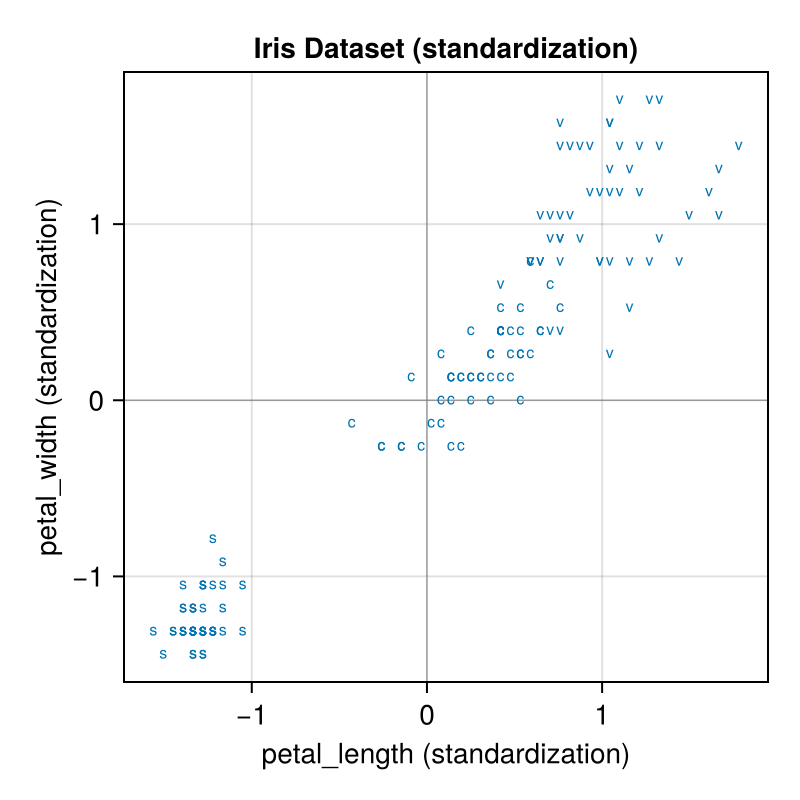

In [6]:
# (1)品種別のマークの配列を準備
markers_dicts = Dict(
    "setosa" => 's',
    "versicolor" => 'c', 
    "virginica" => 'v')
markers = [markers_dicts[s] for s in Species]

# (2)散布図のプロット
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1])
vlines!(ax, [0.0], color = :gray50, linewidth = 0.5) # x=0 の縦線
hlines!(ax, [0.0], color = :gray50, linewidth = 0.5) # y=0 の横線
plt = scatter!(ax, petal_length_z, petal_width_z,
    marker=markers,
    markersize=8)
ax.xlabel = "petal_length (standardization)"
ax.ylabel = "petal_width (standardization)"
ax.title = "Iris Dataset (standardization)"

# グラフの保存と表示
save("iris_standardization_plot.png", fig)  # 保存
fig # 表示